In [4]:
import os
# 1. Λύνει το Warning του KMeans για τη μνήμη στα Windows
os.environ["OMP_NUM_THREADS"] = "1"

# 2. Λύνει το Warning της threadpoolctl αναγκάζοντας το MKL να συνεργαστεί
os.environ["MKL_THREADING_LAYER"] = "GNU"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
cols = ["area", "perimeter", "compactness", "length", "width", "asymmetry", "groove", "class"]
df = pd.read_csv("seeds_dataset.txt", names=cols, sep=r"\s+")

In [6]:
df.head()

,area,perimeter,compactness,length,width,asymmetry,groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


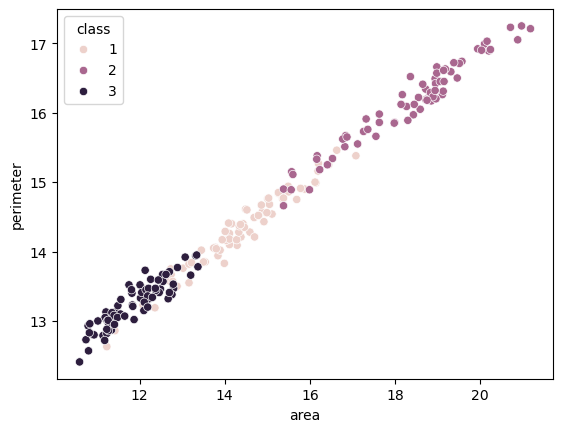

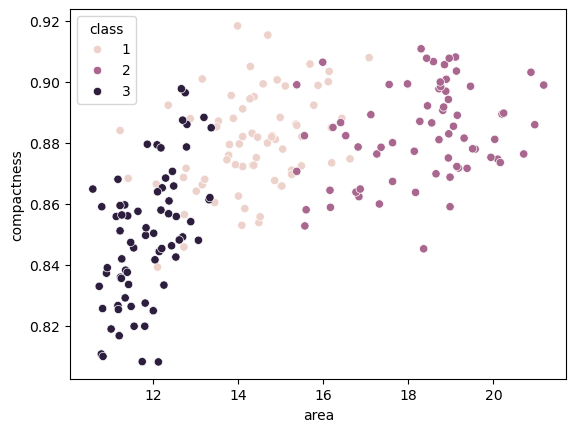

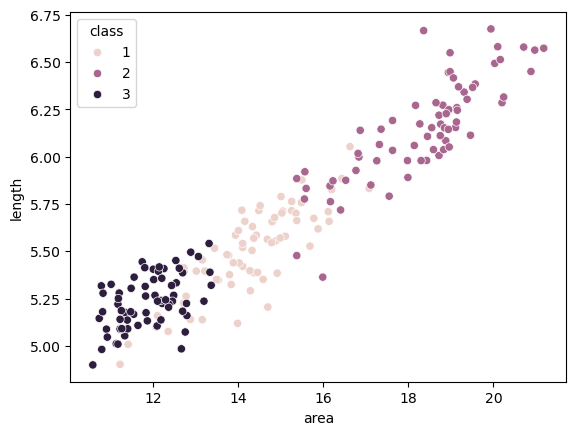

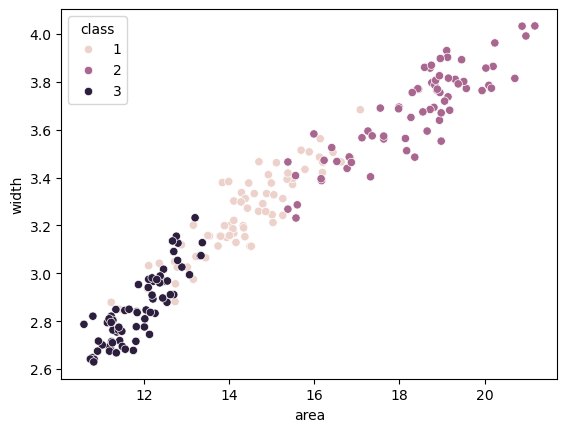

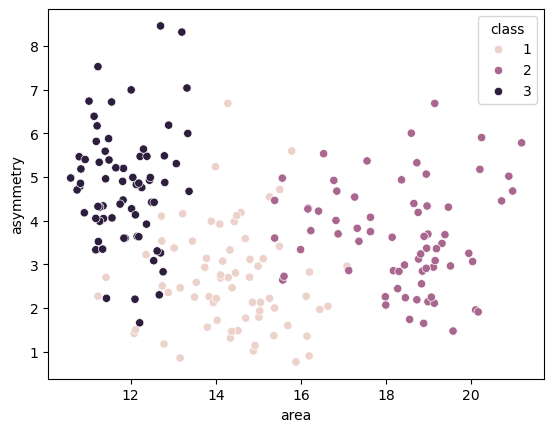

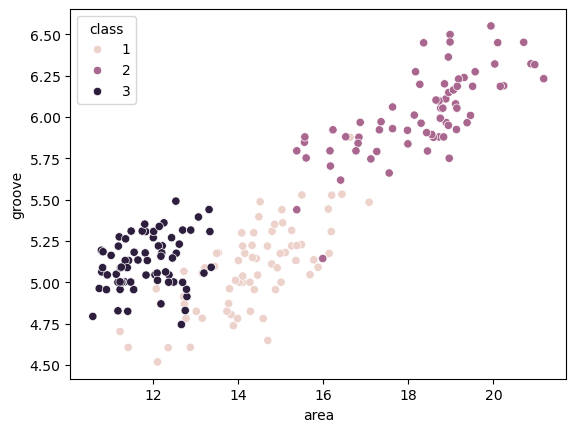

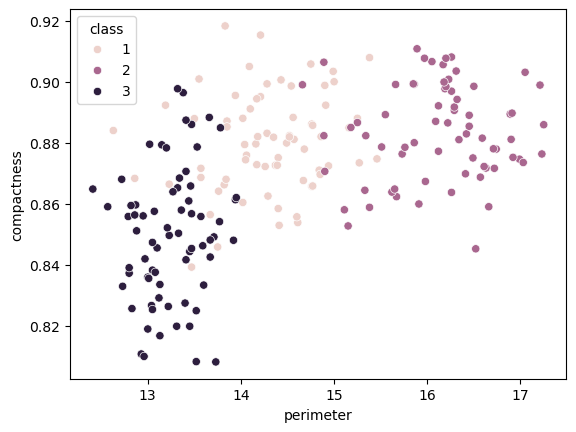

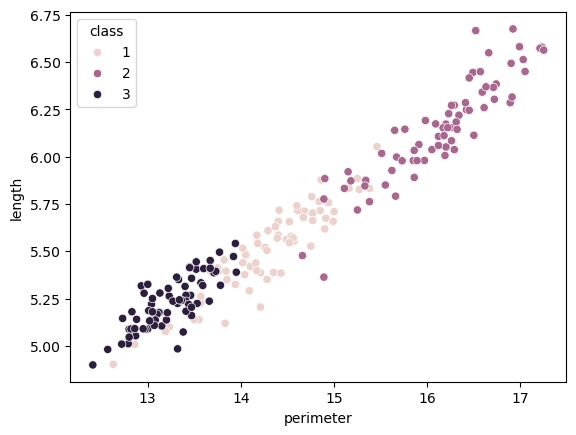

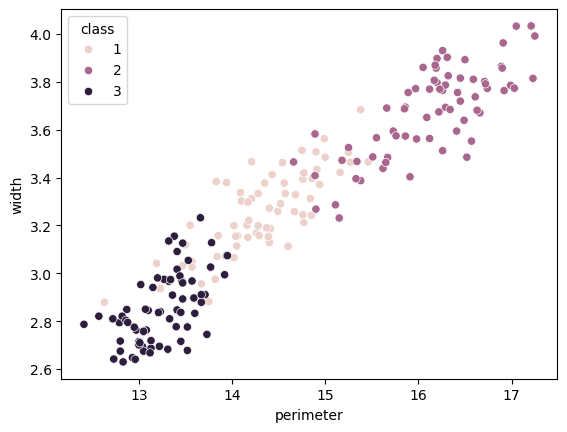

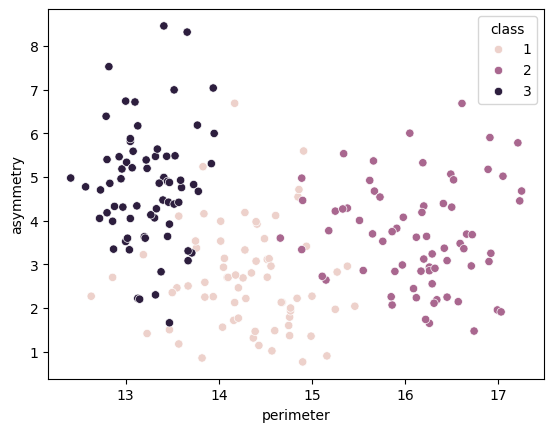

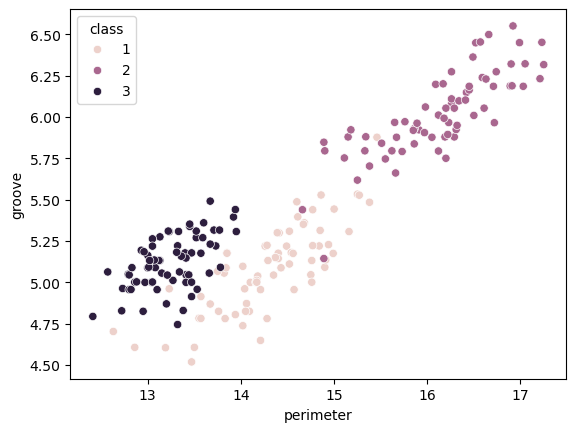

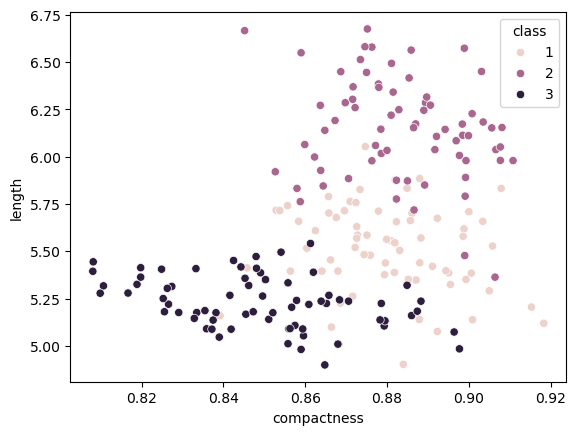

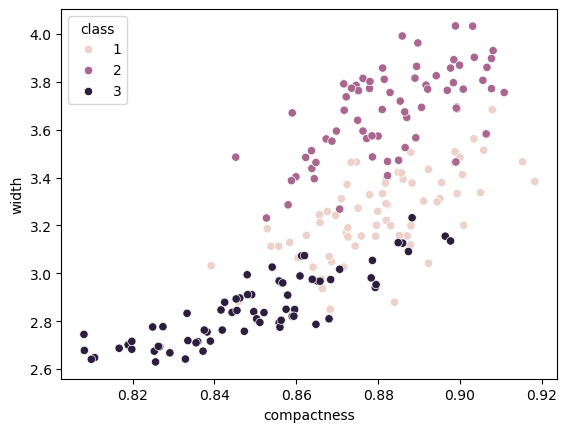

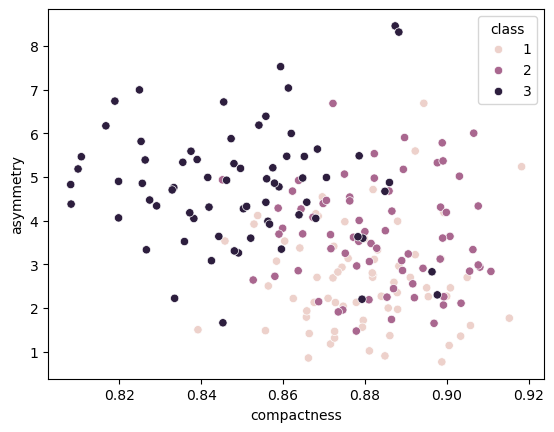

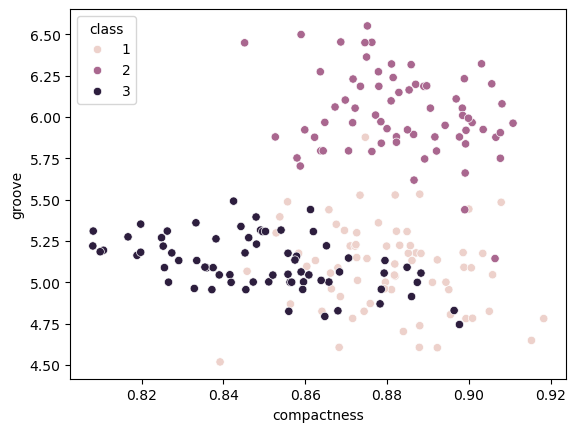

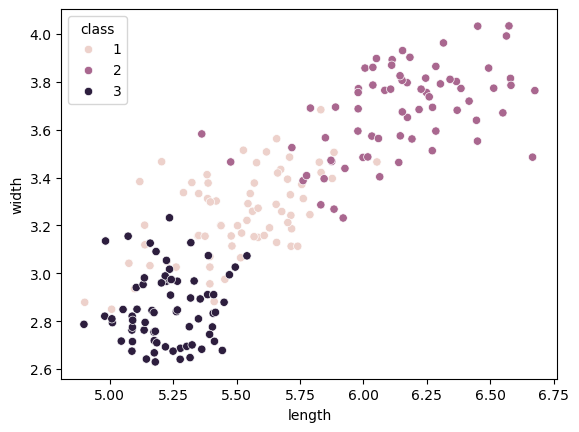

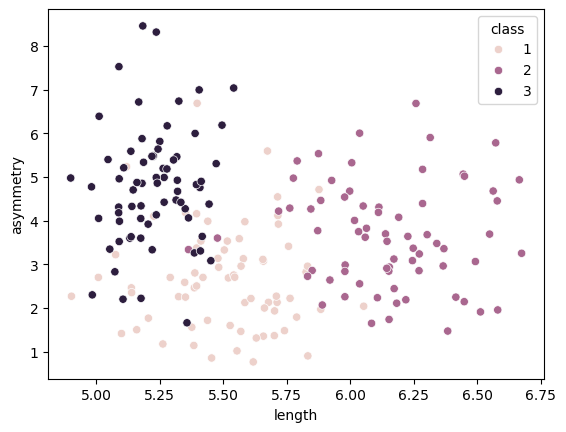

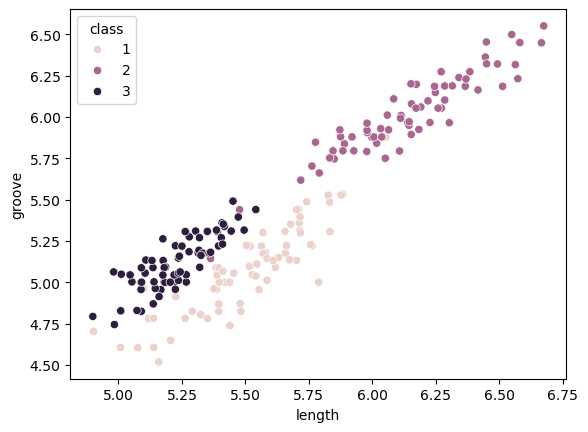

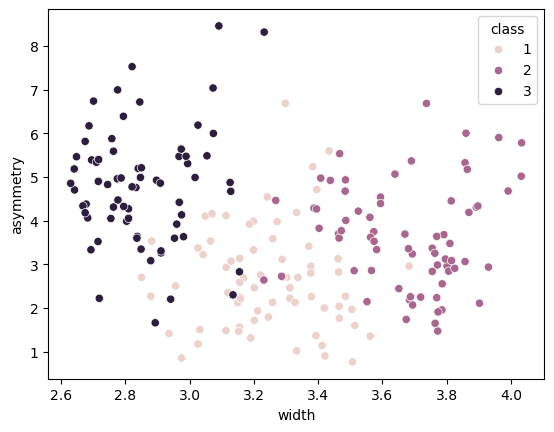

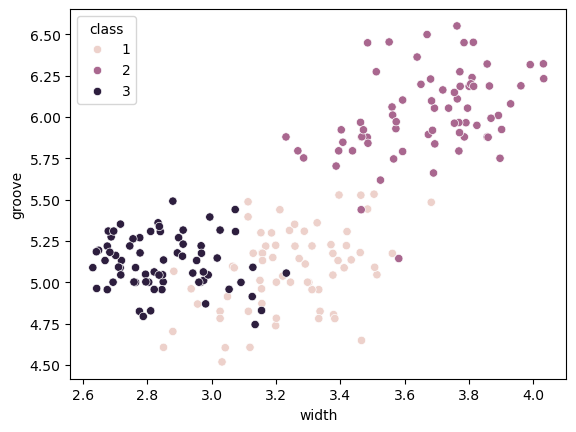

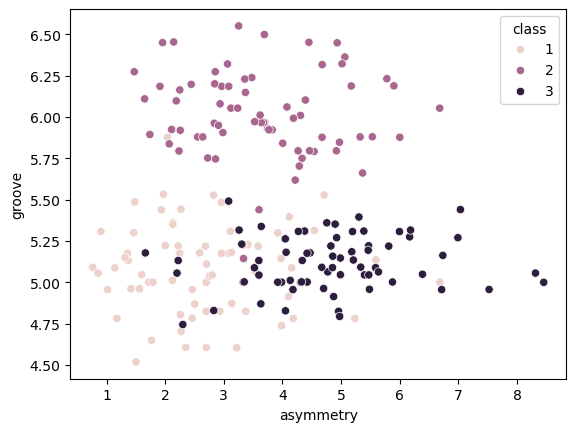

In [7]:
for i in range(len(cols)-1):
    for j in range(i+1, len(cols)-1):
        x_label = cols[i]
        y_label = cols[j]
        sns.scatterplot(x=x_label, y=y_label, data=df, hue="class")
        plt.show()
        

In [8]:
# Clustering
from sklearn.cluster import KMeans

In [29]:
x = "compactness"
y = "asymmetry"
X = df[[x, y]].values

In [30]:
kmeans = KMeans(n_clusters = 3).fit(X)

In [31]:
clusters = kmeans.labels_

In [32]:
cluster_df = pd.DataFrame(np.hstack((X, clusters.reshape(-1, 1))), columns=[x, y, "class"])

[]

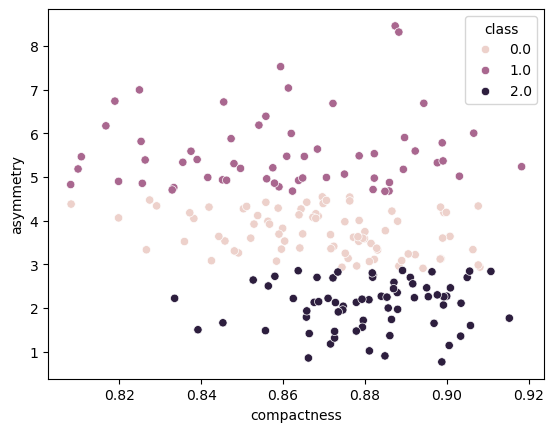

In [33]:
# K Means classes
sns.scatterplot(x=x, y=y, hue="class", data=cluster_df)
plt.plot()


[]

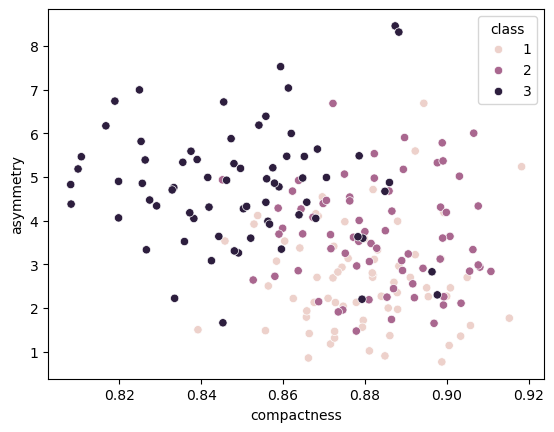

In [34]:
# Original classes
sns.scatterplot(x=x, y=y, hue="class", data=df)
plt.plot()


In [35]:
# Higher Dimensions
X = df[cols[:-1]].values

In [36]:
kmeans = KMeans(n_clusters = 3).fit(X)
cluster_df = pd.DataFrame(np.hstack((X, kmeans.labels_.reshape(-1, 1))), columns=df.columns)

[]

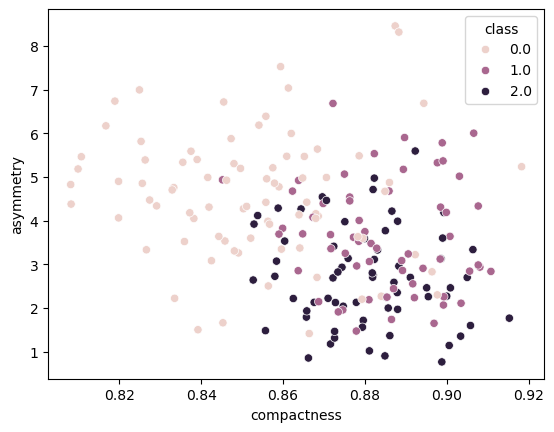

In [37]:
# K Means classes
sns.scatterplot(x=x, y=y, hue="class", data=cluster_df)
plt.plot()

[]

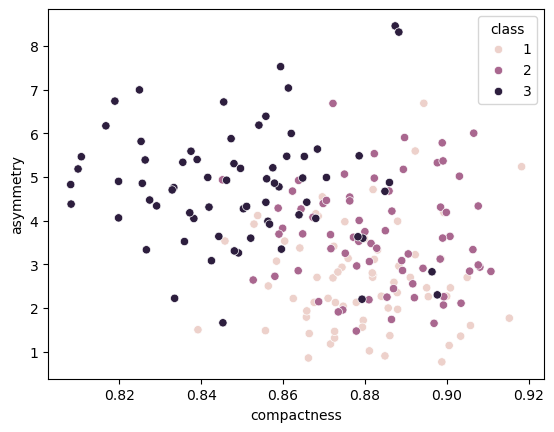

In [38]:
# Original classes
sns.scatterplot(x=x, y=y, hue="class", data=df)
plt.plot()

In [39]:
# PCA
from sklearn.decomposition import PCA

In [47]:
pca = PCA(n_components=2)
transformed_x = pca.fit_transform(X)

In [48]:
X.shape

(210, 7)

In [49]:
transformed_x.shape

(210, 2)

In [50]:
transformed_x[:5]

array([[ 0.66344838, -1.41732098],
       [ 0.31566651, -2.68922915],
       [-0.6604993 , -1.13150635],
       [-1.0552759 , -1.62119002],
       [ 1.61999921, -2.18338442]])

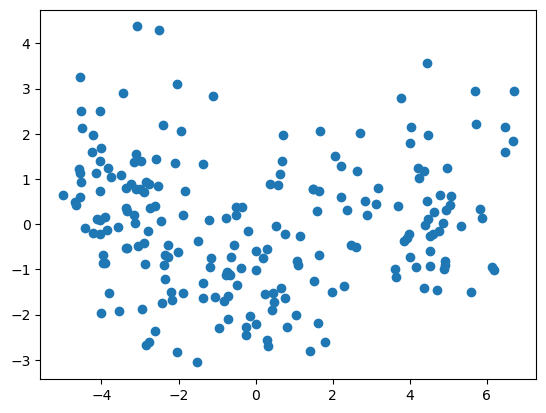

In [53]:
plt.scatter(transformed_x[:,0], transformed_x[:,1])
plt.show()

In [54]:
kmeans_pca_df = pd.DataFrame(np.hstack((transformed_x, kmeans.labels_.reshape(-1, 1))), columns=["pca1", "pca2", "class"]) 

In [55]:
truth_pca_df = pd.DataFrame(np.hstack((transformed_x, df["class"].values.reshape(-1, 1))), columns=["pca1", "pca2", "class"])

[]

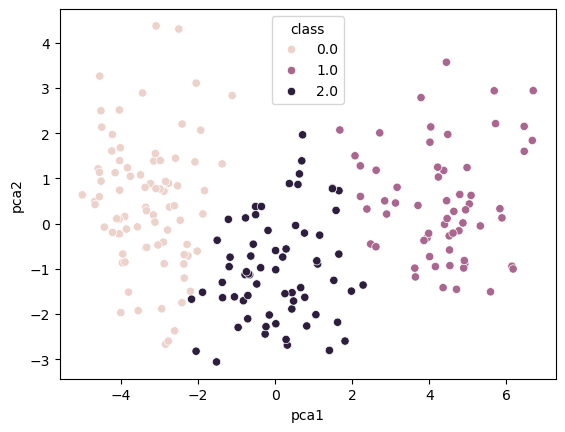

In [58]:
# K Means classes
sns.scatterplot(x="pca1", y="pca2", hue="class", data=kmeans_pca_df)
plt.plot()

[]

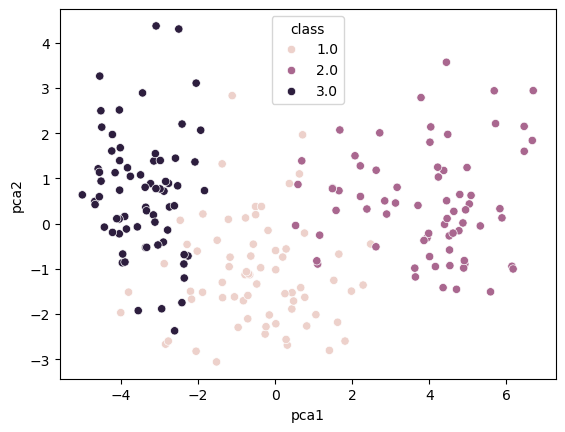

In [59]:
# Truth classes
sns.scatterplot(x="pca1", y="pca2", hue="class", data=truth_pca_df)
plt.plot()